In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# re(reguler expressions) used for text cleaning
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Load dataset
df = pd.read_csv('D:\Sentiment_Analysis\data\IMDB Dataset.csv')

df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [4]:
# cleanig function
def clean_text(text):
    # lowercase
    text = text.lower()

    # remove HTML tag
    text = re.sub(r"<.*?>", "", text)

    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove numbers & punctuation
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


In [5]:
text = clean_text("Hello!!! I paid $50 for this <br> movie :( www.example.com")
clean_text(text)

'hello i paid for this movie'

In [6]:
df['clean_review'] = df['review'].apply(clean_text)

df.head(15)


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story of...
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative idea...
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...


In [7]:
import inspect
print(inspect.getsource(clean_text)) 
# show the source code of function help in debug


def clean_text(text):
    # lowercase
    text = text.lower()

    # remove HTML tag
    text = re.sub(r"<.*?>", "", text)

    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove numbers & punctuation
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()



In [8]:
tfid = TfidfVectorizer(max_features = 5000)
# text --> numbers & max features se top 5000 word lega(reduce noise)

X = tfid.fit_transform(df['clean_review'])

df['label'] = df['sentiment'].map({
    "positive" : 1,
    "negative" : 0
})
# naya column bana liya sentiment ka label nam ka(0 & 1)
y = df['label']


In [9]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: label, Length: 50000, dtype: int64

In [10]:
X
# TF-IDF sparse matrix deta hai numpy array ni
# scikit-learn stores only non-zero values → this is called a sparse matrix.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5814887 stored elements and shape (50000, 5000)>

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc


In [13]:
# models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier()
}


In [14]:

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities or Decision Score
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For LinearSVC (no predict_proba)
        y_prob = model.decision_function(X_test)

    # Save results
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred)
    }

    print(f"{name} Accuracy: {results[name]['accuracy']:.4f}")

    # {results[name]['accuracy']:.4f  --> gives accuracy 


Training Logistic Regression...
Logistic Regression Accuracy: 0.8940

Training Linear SVM...
Linear SVM Accuracy: 0.8894

Training Naive Bayes...
Naive Bayes Accuracy: 0.8521

Training Random Forest...
Random Forest Accuracy: 0.8491


In [15]:
results.keys()

dict_keys(['Logistic Regression', 'Linear SVM', 'Naive Bayes', 'Random Forest'])

In [16]:
for name, res in results.items():
    print(f"Confusion Matrix for {name}:")
    
    cm = confusion_matrix(y_test, res["y_pred"])
    print(cm)
    print("\n")

Confusion Matrix for Logistic Regression:
[[4372  589]
 [ 471 4568]]


Confusion Matrix for Linear SVM:
[[4366  595]
 [ 511 4528]]


Confusion Matrix for Naive Bayes:
[[4229  732]
 [ 747 4292]]


Confusion Matrix for Random Forest:
[[4245  716]
 [ 793 4246]]




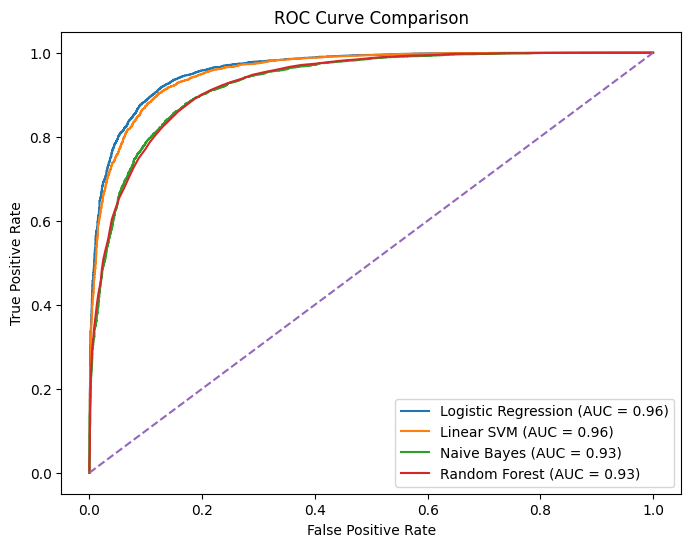

In [17]:
plt.figure(figsize=(8,6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [18]:
print(f"Final Comparison of All Models:\n")

for name, res in results.items():
    print("="*50)
    print(f"MODEL: {name}")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(classification_report(y_test, res["y_pred"]))
    print("="*50)


Final Comparison of All Models:

MODEL: Logistic Regression
Accuracy: 0.8940
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

MODEL: Linear SVM
Accuracy: 0.8894
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

MODEL: Naive Bayes
Accuracy: 0.8521
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                      

In [19]:
best_model_name = None
best_accuracy = 0.0


for name, res in results.items():
    print(f"{name}): Accuracy = {res['accuracy']:.4f}")

    if res["accuracy"] > best_accuracy:
        best_accuracy = res["accuracy"]
        best_model_name = name

print("\nBest model is:", best_model_name)
print("Best Accuracy =", best_accuracy)

        

Logistic Regression): Accuracy = 0.8940
Linear SVM): Accuracy = 0.8894
Naive Bayes): Accuracy = 0.8521
Random Forest): Accuracy = 0.8491

Best model is: Logistic Regression
Best Accuracy = 0.894


In [20]:
joblib.dump(tfid, r"D:/Sentiment_Analysis/models/tfidf_vectorizer.pkl")

joblib.dump(results[best_model_name]["model"],
            fr"D:/Sentiment_Analysis/models/{best_model_name}_model.pkl")


['D:/Sentiment_Analysis/models/Logistic Regression_model.pkl']